Total de Registros: 284,807
Total de Colunas: 31
Valores Ausentes (NaN): 0
Transações Legítimas (0): 284,315 (99.827%)
Transações Fraudulentas (1): 492 (0.173%)


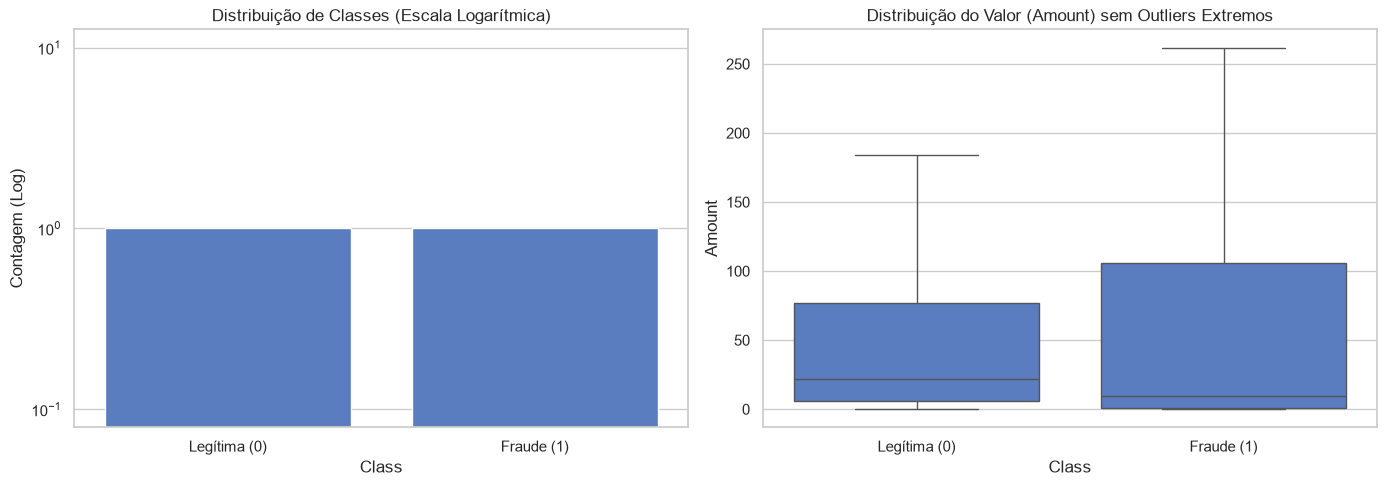

Pré-processamento e dimensionamento concluídos com sucesso!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

# Configurações visuais
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.size'] = 11

df = pd.read_csv('creditcard.csv')

print("="*50)
print(f"Total de Registros: {df.shape[0]:,}")
print(f"Total de Colunas: {df.shape[1]}")
print("Valores Ausentes (NaN):", df.isnull().sum().sum())
print("="*50)

# 1. Diagnóstico do Desbalanceamento
fraudes = df[df['Class'] == 1]
legitimas = df[df['Class'] == 0]

qtd_fraudes = len(fraudes)
qtd_legitimas = len(legitimas)
pct_fraudes = (qtd_fraudes / len(df)) * 100

print(f"Transações Legítimas (0): {qtd_legitimas:,} ({100 - pct_fraudes:.3f}%)")
print(f"Transações Fraudulentas (1): {qtd_fraudes:,} ({pct_fraudes:.3f}%)")
print("="*50)

# 2. Visualização do Desbalanceamento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras do desbalanceamento
sns.countplot(data=df, x='Class', ax=axes[0], log=True)
axes[0].set_title('Distribuição de Classes (Escala Logarítmica)')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Legítima (0)', 'Fraude (1)'])
axes[0].set_ylabel('Contagem (Log)')

# Distribuição do Valor da Transação por Classe
sns.boxplot(data=df, x='Class', y='Amount', ax=axes[1], showfliers=False)
axes[1].set_title('Distribuição do Valor (Amount) sem Outliers Extremos')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Legítima (0)', 'Fraude (1)'])

plt.tight_layout()
plt.show()

# 5. Escalonamento de 'Time' e 'Amount'
scaler = RobustScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

df.drop(['Time', 'Amount'], axis=1, inplace=True)

print("Pré-processamento e dimensionamento concluídos com sucesso!")

In [2]:
%%capture
!pip install -q xgboost imbalanced-learn

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
import pandas as pd

# 1. Separação de Variáveis Explicativas (X) e Alvo (y)
X = df.drop('Class', axis=1)
y = df['Class']

# 2. Divisão Estratificada em Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dataset de Treino: {X_train.shape[0]:,} amostras")
print(f"Dataset de Teste:  {X_test.shape[0]:,} amostras (contém {y_test.sum()} fraudes)")
print("="*60)

# Dicionário para guardar resultados
resultados = []

# --- MODELO 1: Regressão Logística (Baseline) ---
print("\n[1/3] Treinando Regressão Logística (Baseline)...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

resultados.append({
    'Modelo': 'Regressão Logística',
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall (Fraudes Detectadas)': recall_score(y_test, y_pred_lr),
    'F1-Score': f1_score(y_test, y_pred_lr)
})

# --- MODELO 2: XGBoost Weighted ---
print("\n[2/3] Treinando XGBoost com Ajuste de Pesos...")
ratio = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

resultados.append({
    'Modelo': 'XGBoost (Weighted)',
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall (Fraudes Detectadas)': recall_score(y_test, y_pred_xgb),
    'F1-Score': f1_score(y_test, y_pred_xgb)
})

# --- MODELO 3: XGBoost + SMOTE ---
print("\n[3/3] Aplicando SMOTE e Treinando XGBoost...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

xgb_smote_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_smote_model.fit(X_train_smote, y_train_smote)
y_pred_xgb_smote = xgb_smote_model.predict(X_test)

resultados.append({
    'Modelo': 'XGBoost + SMOTE',
    'Precision': precision_score(y_test, y_pred_xgb_smote),
    'Recall (Fraudes Detectadas)': recall_score(y_test, y_pred_xgb_smote),
    'F1-Score': f1_score(y_test, y_pred_xgb_smote)
})

# --- TABELA COMPARATIVA ---
print("\n" + "="*60)
print("RESUMO COMPARATIVO DOS MODELOS")
print("="*60)
df_resumo = pd.DataFrame(resultados)
print(df_resumo.to_string(index=False))

Dataset de Treino: 227,845 amostras
Dataset de Teste:  56,962 amostras (contém 98 fraudes)

[1/3] Treinando Regressão Logística (Baseline)...

[2/3] Treinando XGBoost com Ajuste de Pesos...

[3/3] Aplicando SMOTE e Treinando XGBoost...

RESUMO COMPARATIVO DOS MODELOS
             Modelo  Precision  Recall (Fraudes Detectadas)  F1-Score
Regressão Logística   0.818182                     0.642857  0.720000
 XGBoost (Weighted)   0.890110                     0.826531  0.857143
    XGBoost + SMOTE   0.732759                     0.867347  0.794393


Limiar Padrão (0.50) -> Prejuízo Estimado: R$ 8,600.00
Limiar Ótimo (0.01) -> Prejuízo Estimado: R$ 6,740.00
ECONOMIA GERADA COM OTIMIZAÇÃO: R$ 1,860.00


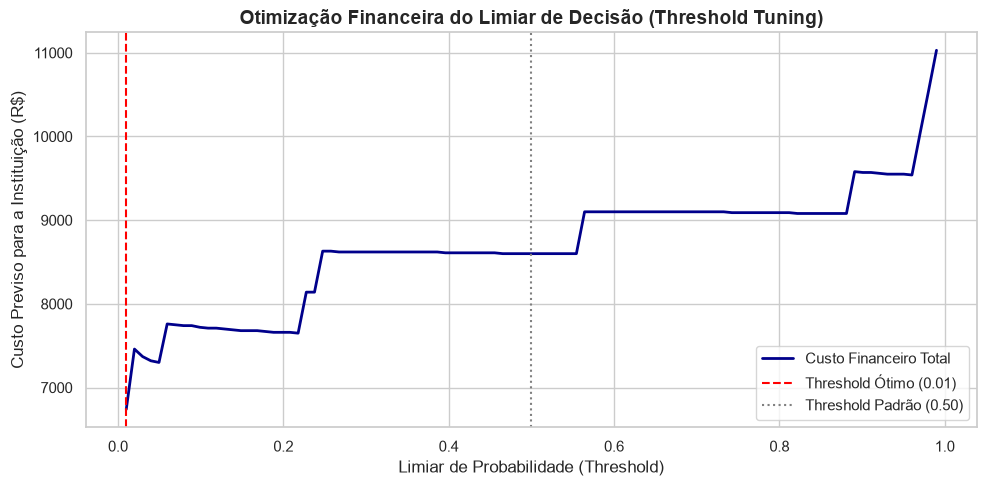

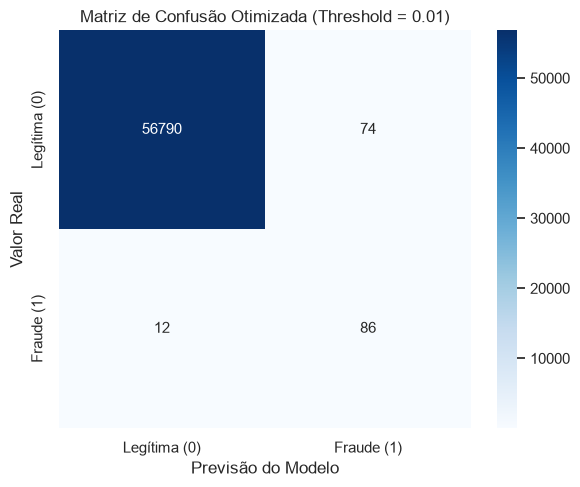

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, confusion_matrix

# 1. Obtenção das probabilidades calculadas pelo XGBoost Weighted
y_probs = xgb_model.predict_proba(X_test)[:, 1]

# 2. Definição da Matriz de Custos de Negócio (em R$)
CUSTO_FN = 500.0  # Custo de perder uma fraude não detectada
CUSTO_FP = 10.0   # Custo de incomodar um cliente legítimo

# 3. Testando 100 diferentes limiares (thresholds) de decisão
thresholds = np.linspace(0.01, 0.99, 100)
custos_totais = []

for t in thresholds:
    y_pred_temp = (y_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_temp).ravel()
    
    # Custo total = (Fraudes não pegas * R$500) + (Alarmes falsos * R$10)
    custo_total = (fn * CUSTO_FN) + (fp * CUSTO_FP)
    custos_totais.append(custo_total)

# 4. Identificando o Limiar de Custo Mínimo
melhor_idx = np.argmin(custos_totais)
melhor_threshold = thresholds[melhor_idx]
menor_custo = custos_totais[melhor_idx]

# Custo com o threshold padrão de 0.50
pred_padrao = (y_probs >= 0.50).astype(int)
tn_p, fp_p, fn_p, tp_p = confusion_matrix(y_test, pred_padrao).ravel()
custo_padrao = (fn_p * CUSTO_FN) + (fp_p * CUSTO_FP)

economia = custo_padrao - menor_custo

print("="*60)
print(f"Limiar Padrão (0.50) -> Prejuízo Estimado: R$ {custo_padrao:,.2f}")
print(f"Limiar Ótimo ({melhor_threshold:.2f}) -> Prejuízo Estimado: R$ {menor_custo:,.2f}")
print(f"ECONOMIA GERADA COM OTIMIZAÇÃO: R$ {economia:,.2f}")
print("="*60)

# 5. Visualização da Curva de Custo x Limiar
plt.figure(figsize=(10, 5))
plt.plot(thresholds, custos_totais, color='darkblue', lw=2, label='Custo Financeiro Total')
plt.axvline(x=melhor_threshold, color='red', linestyle='--', label=f'Threshold Ótimo ({melhor_threshold:.2f})')
plt.axvline(x=0.50, color='gray', linestyle=':', label='Threshold Padrão (0.50)')

plt.title('Otimização Financeira do Limiar de Decisão (Threshold Tuning)', fontsize=14, fontweight='bold')
plt.xlabel('Limiar de Probabilidade (Threshold)')
plt.ylabel('Custo Previso para a Instituição (R$)')
plt.legend()
plt.tight_layout()
plt.show()

# 6. Matriz de Confusão Otimizada
y_pred_otimo = (y_probs >= melhor_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_otimo)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Legítima (0)', 'Fraude (1)'], 
            yticklabels=['Legítima (0)', 'Fraude (1)'])
plt.title(f'Matriz de Confusão Otimizada (Threshold = {melhor_threshold:.2f})')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()